In [266]:
import pandas as pd
from glob import glob
import os
import numpy as np
from tqdm import tqdm
from scipy.stats import iqr
import mhcgnomes
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',500)
pd.set_option('display.max_rows',500)

## Charged

In [25]:
!cat /projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/report.txt


+--------------------------------------------------+---------------+
|              📊 СТАТИСТИКА PIPELINE              |               |
+--------------------------------------------------+---------------+
| Всего задач в samplesheet                        | 80           |
| Уникальных моделей                               | 80           |
| Успешно построено                                | 80           |
| Процент успеха (модели)                          | 100.0%       |
| Уникальных тестирований                          | 0            |
| Успешно проведено                                | 0            |
| Процент успеха (тесты)                           | 0%           |
+--------------------------------------------------+---------------+
Дата: 2026-03-30 20:01:01


In [35]:
charged_samplesheet = pd.read_csv("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/output_samplesheet.csv")
charged_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST


In [36]:
charged_logs = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/train_results/*.csv")
len(charged_logs)

80

In [37]:
charged_samplesheet["basename"] = charged_samplesheet["train_file"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
charged_samplesheet[["Structure", "Activity", "Species"]] = charged_samplesheet["basename"].str.split("_",expand=True)
charged_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human


In [38]:
metrics_tbls = []
for i in tqdm(charged_samplesheet.index):
    metrics_path = os.path.join("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/train_results",f"{charged_samplesheet.loc[i,'train_id']}.csv")
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path, sep = ";")
        metrics['train_id'] = charged_samplesheet.loc[i,'train_id']
        metrics_tbls.append(metrics)
total_metrics = pd.concat(metrics_tbls, ignore_index=True)
ch_samplesheet_metrics = pd.merge(charged_samplesheet, total_metrics, on = 'train_id')
ch_samplesheet_metrics['type'] = 'charged'
print(ch_samplesheet_metrics.shape)
ch_samplesheet_metrics.head()

100%|██████████| 80/80 [00:00<00:00, 503.02it/s]


(11253, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8261,0.7141,0.6437,56391,11,0.0004,7,36297,20094,4,AAFKRSCLK,56402,0.636364,0.643667,0.008165,0.000799,charged
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8354,0.6784,0.6009,56391,11,0.0003,7,33884,22507,4,AAGIGILTV,56402,0.636364,0.600876,0.006765,0.000600,charged
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7449,0.7082,0.6456,56388,14,0.0005,9,36404,19984,5,AIFYLITPV,56402,0.642857,0.645598,0.009499,0.000999,charged
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9438,0.9476,0.6968,56398,4,0.0002,3,39297,17101,1,AIILASFSA,56402,0.750000,0.696780,0.008185,0.000400,charged
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9687,0.9732,0.7435,56399,3,0.0002,2,41934,14465,1,AIMDKNIIL,56402,0.666667,0.743524,0.006850,0.000400,charged


## Neutral

In [39]:
!cat /projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/report.txt


+--------------------------------------------------+---------------+
|              📊 СТАТИСТИКА PIPELINE              |               |
+--------------------------------------------------+---------------+
| Всего задач в samplesheet                        | 80           |
| Уникальных моделей                               | 80           |
| Успешно построено                                | 80           |
| Процент успеха (модели)                          | 100.0%       |
| Уникальных тестирований                          | 0            |
| Успешно проведено                                | 0            |
| Процент успеха (тесты)                           | 0%           |
+--------------------------------------------------+---------------+
Дата: 2026-03-30 20:38:31


In [40]:
neutral_samplesheet = pd.read_csv("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/output_samplesheet.csv")
neutral_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST


In [41]:
neutral_logs = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/*.csv")
len(neutral_logs)

80

In [42]:
neutral_samplesheet["basename"] = neutral_samplesheet["train_file"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
neutral_samplesheet[["Structure", "Activity", "Species"]] = neutral_samplesheet["basename"].str.split("_",expand=True)
neutral_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human


In [43]:
metrics_tbls = []
for i in tqdm(neutral_samplesheet.index):
    metrics_path = os.path.join("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results",f"{neutral_samplesheet.loc[i,'train_id']}.csv")
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path, sep = ";")
        metrics['train_id'] = neutral_samplesheet.loc[i,'train_id']
        metrics_tbls.append(metrics)
total_metrics = pd.concat(metrics_tbls, ignore_index=True)
n_samplesheet_metrics = pd.merge(neutral_samplesheet, total_metrics, on = 'train_id')
n_samplesheet_metrics['type'] = 'neutral'
print(n_samplesheet_metrics.shape)
n_samplesheet_metrics.head()

100%|██████████| 80/80 [00:00<00:00, 403.10it/s]

(11187, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8249,0.8205,0.7068,56391,11,0.0005,8,39855,16536,3,AAFKRSCLK,56402,0.727273,0.706762,0.013312,0.000999,neutral
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8319,0.7853,0.6601,56391,11,0.0004,7,37221,19170,4,AAGIGILTV,56402,0.636364,0.660052,0.008738,0.000799,neutral
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7462,0.7793,0.6873,56388,14,0.0005,10,38755,17633,4,AIFYLITPV,56402,0.714286,0.687292,0.013644,0.000999,neutral
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9429,0.9455,0.6925,56398,4,0.0002,3,39055,17343,1,AIILASFSA,56402,0.750000,0.692489,0.008075,0.000400,neutral
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9680,0.9719,0.7371,56399,3,0.0001,2,41572,14827,1,AIMDKNIIL,56402,0.666667,0.737105,0.006689,0.000200,neutral


## Total

In [85]:
total = pd.concat([ch_samplesheet_metrics,n_samplesheet_metrics],ignore_index=True)
total["mna_level"] = total["mna_level"].astype('category')
print(total.shape)
total.head()

(22440, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8261,0.7141,0.6437,56391,11,0.0004,7,36297,20094,4,AAFKRSCLK,56402,0.636364,0.643667,0.008165,0.000799,charged
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8354,0.6784,0.6009,56391,11,0.0003,7,33884,22507,4,AAGIGILTV,56402,0.636364,0.600876,0.006765,0.000600,charged
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7449,0.7082,0.6456,56388,14,0.0005,9,36404,19984,5,AIFYLITPV,56402,0.642857,0.645598,0.009499,0.000999,charged
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9438,0.9476,0.6968,56398,4,0.0002,3,39297,17101,1,AIILASFSA,56402,0.750000,0.696780,0.008185,0.000400,charged
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9687,0.9732,0.7435,56399,3,0.0002,2,41934,14465,1,AIMDKNIIL,56402,0.666667,0.743524,0.006850,0.000400,charged


In [86]:
grouped = total.groupby(["Structure", 'Activity','Species', 'type','mna_level']).agg(
        n_activity=pd.NamedAgg(column='5-F CV', aggfunc='size'),
        median5CV=pd.NamedAgg(column='5-F CV', aggfunc='median'),
        iqr5CV=pd.NamedAgg(column='5-F CV', aggfunc=iqr),
        mean_precision=pd.NamedAgg(column='Prec.', aggfunc='mean'),
        mean_sensivity=pd.NamedAgg(column='Sens.', aggfunc='mean'),
        mean_specifity=pd.NamedAgg(column='Spec.', aggfunc='mean'),
        sample_size=pd.NamedAgg(column='sample_size', aggfunc='max')
).reset_index()
grouped["Structure"] = grouped["Structure"].replace({'cdr3alpha': "α", 'cdr3beta': "β"})
grouped["Species"] = grouped["Species"].replace({'human': "Человек", 'mouse': "Мышь"})
grouped["Activity"] = grouped["Activity"].replace({'epitope': "Эпитопы", 'mhc': "MHC"})
grouped["type"] = grouped["type"].replace({'charged': "Заряженные", 'neutral': "Нейтральные"})
grouped = grouped.rename(columns = {
"Structure":"Цепь",
"Species":"Вид",
"type":"Тип дескриптора",
"mna_level":"Уровень MNA",
"median5CV":"Медиана ROC AUC",
"iqr5CV":"IQR ROC AUC"
})
grouped.head()

/scratch/ipykernel_3339613/1102259902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = total.groupby(["Structure", 'Activity','Species', 'type','mna_level']).agg(


,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,n_activity,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
0,α,Эпитопы,Человек,Заряженные,3,471,0.8108,0.150050,0.002460,0.668706,0.665254,56402
1,α,Эпитопы,Человек,Заряженные,4,519,0.8237,0.186850,0.002209,0.685577,0.687246,71503
2,α,Эпитопы,Человек,Заряженные,5,116,0.8422,0.201175,0.001021,0.714254,0.727724,72429
3,α,Эпитопы,Человек,Заряженные,6,433,0.8638,0.181500,0.003216,0.767493,0.763700,72608
4,α,Эпитопы,Человек,Заряженные,7,299,0.8813,0.209050,0.003462,0.815909,0.800203,72624


In [87]:
epitope = grouped.query("Activity == 'Эпитопы'").rename(columns = {"n_activity":"Кол-во эпитопов"})
epitope.head()

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во эпитопов,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
0,α,Эпитопы,Человек,Заряженные,3,471,0.8108,0.150050,0.002460,0.668706,0.665254,56402
1,α,Эпитопы,Человек,Заряженные,4,519,0.8237,0.186850,0.002209,0.685577,0.687246,71503
2,α,Эпитопы,Человек,Заряженные,5,116,0.8422,0.201175,0.001021,0.714254,0.727724,72429
3,α,Эпитопы,Человек,Заряженные,6,433,0.8638,0.181500,0.003216,0.767493,0.763700,72608
4,α,Эпитопы,Человек,Заряженные,7,299,0.8813,0.209050,0.003462,0.815909,0.800203,72624


In [90]:
epitope.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 119
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Цепь             80 non-null     object  
 1   Activity         80 non-null     object  
 2   Вид              80 non-null     object  
 3   Тип дескриптора  80 non-null     object  
 4   Уровень MNA      80 non-null     category
 5   Кол-во эпитопов  80 non-null     int64   
 6   Медиана ROC AUC  80 non-null     float64 
 7   IQR ROC AUC      80 non-null     float64 
 8   mean_precision   80 non-null     float64 
 9   mean_sensivity   80 non-null     float64 
 10  mean_specifity   80 non-null     float64 
 11  sample_size      80 non-null     int64   
dtypes: category(1), float64(5), int64(2), object(4)
memory usage: 7.9+ KB


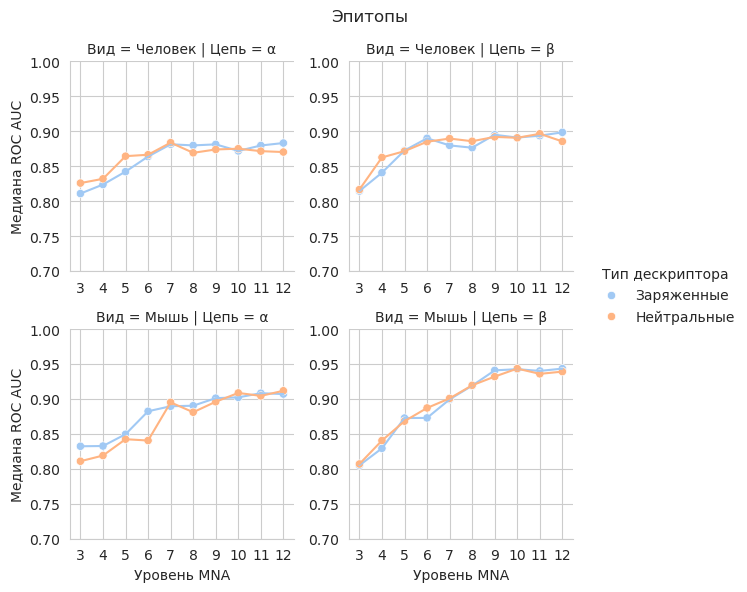

In [193]:
g = sns.FacetGrid(epitope,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],ylim=(0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'Эпитопы')
for (s,c), ax in g.axes_dict.items():
    ax.set_xticks(np.arange(3,13,1))
g.tight_layout()
plt.savefig("../plots/tmp/auroc_ch_vs_n_epi.png", dpi = 400)

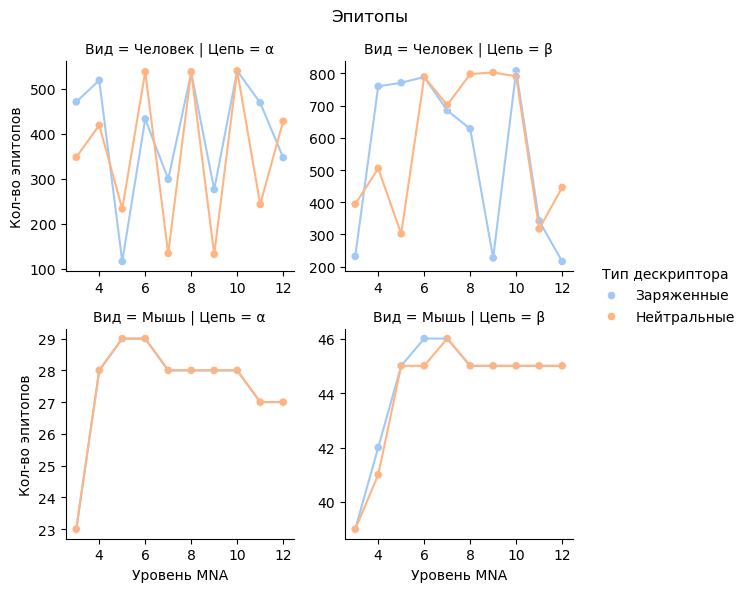

In [70]:
g = sns.FacetGrid(epitope,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"])
g.map(sns.lineplot,"Уровень MNA","Кол-во эпитопов","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Кол-во эпитопов","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'Эпитопы')
g.tight_layout()

In [71]:
epitope.query("`Вид`=='Мышь' and `Цепь`=='α'")

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во эпитопов,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
20,α,Эпитопы,Мышь,Заряженные,3,23,0.83230,0.168700,0.053617,0.699947,0.696938,2845
21,α,Эпитопы,Мышь,Заряженные,4,28,0.83265,0.159875,0.072071,0.726147,0.724158,3382
22,α,Эпитопы,Мышь,Заряженные,5,29,0.84950,0.129000,0.079110,0.756234,0.739226,3396
23,α,Эпитопы,Мышь,Заряженные,6,29,0.88240,0.093000,0.091717,0.783231,0.775584,3399
24,α,Эпитопы,Мышь,Заряженные,7,28,0.88955,0.082000,0.105557,0.795125,0.795550,3399
25,α,Эпитопы,Мышь,Заряженные,8,28,0.89030,0.093725,0.116907,0.818888,0.813280,3401
26,α,Эпитопы,Мышь,Заряженные,9,28,0.90115,0.075450,0.119825,0.793659,0.802770,3401
27,α,Эпитопы,Мышь,Заряженные,10,28,0.90225,0.073700,0.127275,0.810826,0.818109,3401
28,α,Эпитопы,Мышь,Заряженные,11,27,0.90820,0.065450,0.136837,0.822375,0.829840,3401
29,α,Эпитопы,Мышь,Заряженные,12,27,0.90700,0.101150,0.148848,0.838456,0.833653,3401


In [75]:
total1 = total.query("Structure == 'cdr3alpha' and Species == 'human' and Activity == 'epitope' and mna_level == 5")
total1

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
990,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.9444,0.8376,0.7358,72418,11,0.0004,8,53282,19136,3,AAFKRSCLK,72429,0.727273,0.735756,0.012939,0.000800,charged
991,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.9492,0.7476,0.6594,72418,11,0.0003,7,47755,24663,4,AAGIGILTV,72429,0.636364,0.659435,0.007691,0.000600,charged
992,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,7,0.8545,0.8716,0.7381,72422,7,0.0003,5,53456,18966,2,AEMEFCPCC,72429,0.714286,0.738118,0.010115,0.000600,charged
993,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,14,0.8975,0.7756,0.6712,72415,14,0.0004,9,48602,23813,5,AEVQIDRLI,72429,0.642857,0.671159,0.009292,0.000800,charged
994,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,14,0.9197,0.9155,0.7912,72415,14,0.0007,11,57295,15120,3,AIFYLITPV,72429,0.785714,0.791203,0.019728,0.001399,charged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12248,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,229,Ok,9,0.8595,0.7874,0.6881,72420,9,0.0003,6,49831,22589,3,LLFGMTPCL,72429,0.666667,0.688083,0.008535,0.000600,neutral
12249,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,230,Ok,226,0.7644,0.7390,0.6622,72203,226,0.0061,150,47810,24393,76,LLFGYPVYV,72429,0.663717,0.662161,0.038399,0.012089,neutral
12250,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,231,Ok,10,0.9863,0.9871,0.8382,72419,10,0.0007,8,60700,11719,2,LLFLVLIML,72429,0.800000,0.838178,0.020355,0.001399,neutral
12251,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...

Нерегулярность , так как на разных  уровнях разное кол-во соединений прошло 5CV

In [77]:
mhc = grouped.query("Activity == 'MHC'").rename(columns = {"n_activity":"Кол-во аллелей"})
mhc.head()

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во аллелей,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
40,α,MHC,Человек,Заряженные,3,32,0.7901,0.052225,0.002394,0.706135,0.708700,56402
41,α,MHC,Человек,Заряженные,4,33,0.7934,0.090200,0.002070,0.710435,0.716462,71503
42,α,MHC,Человек,Заряженные,5,39,0.8143,0.067800,0.002241,0.725834,0.721158,72429
43,α,MHC,Человек,Заряженные,6,41,0.8079,0.096800,0.005663,0.737333,0.733617,72608
44,α,MHC,Человек,Заряженные,7,43,0.8178,0.106350,0.009514,0.742900,0.747043,72624


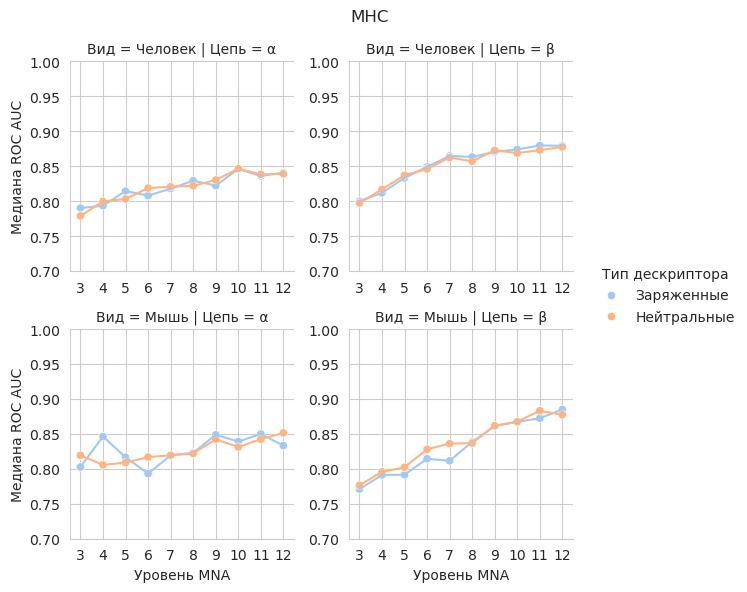

In [194]:
g = sns.FacetGrid(mhc,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],ylim=(0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'MHC')
for (s,c), ax in g.axes_dict.items():
    ax.set_xticks(np.arange(3,13,1))
g.tight_layout()
plt.savefig("../plots/tmp/auroc_ch_vs_n_mhc.png", dpi = 400)

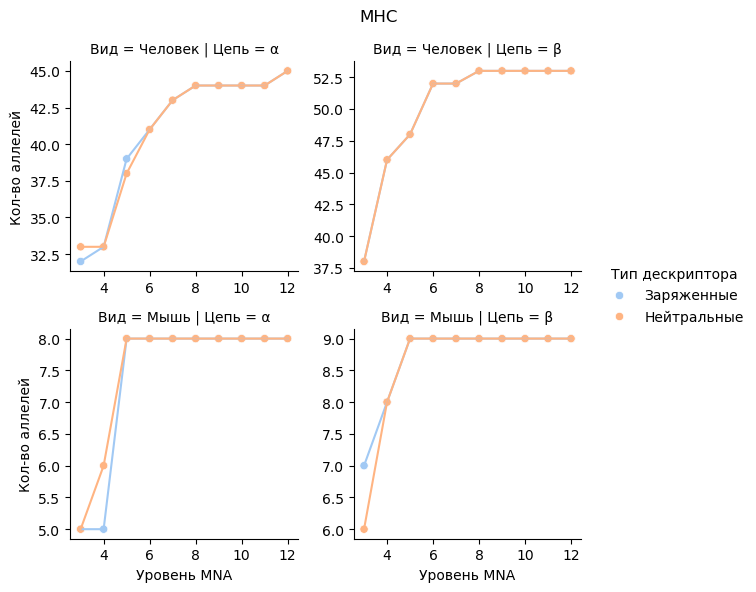

In [93]:
g = sns.FacetGrid(mhc,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"])
g.map(sns.lineplot,"Уровень MNA","Кол-во аллелей","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Кол-во аллелей","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'MHC')
g.tight_layout()

# Article

## data inspection

In [134]:
data_files = sorted(glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/*.csv"))
data_files_2023 = sorted(glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2023/*.csv"))
print(data_files)
print(data_files_2023)

['/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3alpha_epitope_human.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3alpha_epitope_mouse.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3alpha_mhc_human.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3alpha_mhc_mouse.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3beta_epitope_human.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3beta_epitope_mouse.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3beta_mhc_human.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2026/cdr3beta_mhc_mouse.csv']
['/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2023/cdr3alpha_epitope_human.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/data/v2023/cdr3alpha_epitope_mouse.csv', '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/dat

In [135]:
import warnings
warnings.filterwarnings('ignore')
for f,f_old in zip(data_files, data_files_2023):
    filename = os.path.splitext(os.path.basename(f))[0].split("_")
    filename_2023 = os.path.splitext(os.path.basename(f_old))[0].split("_")
    assert filename[0] == filename_2023[0] and filename[1] == filename_2023[1] and filename[2] == filename_2023[2],'incorrect'
    d = pd.read_csv(f, sep = ";")
    d_old = pd.read_csv(f_old, sep = ";")
    old_act = 'Epitope' if filename_2023[1] == 'epitope' else 'MHC_allele'
    print(f"{filename[2]} {filename[0]}={len(d['Structure'].unique())} {filename[1]}={len(d['Activity'].unique())}; Old: {filename[0]}={len(d_old['CDR3_TCR_sequence'].unique())} {filename[1]}={len(d_old[old_act].unique())}")

human cdr3alpha=72630 epitope=1865; Old: cdr3alpha=35616 epitope=799
mouse cdr3alpha=3401 epitope=148; Old: cdr3alpha=1604 epitope=96
human cdr3alpha=72630 mhc=121; Old: cdr3alpha=31066 mhc=76
mouse cdr3alpha=3401 mhc=11; Old: cdr3alpha=1462 mhc=11
human cdr3beta=134026 epitope=2052; Old: cdr3beta=141500 epitope=1257
mouse cdr3beta=6156 epitope=171; Old: cdr3beta=3014 epitope=123
human cdr3beta=134026 mhc=146; Old: cdr3beta=47639 mhc=88
mouse cdr3beta=6156 mhc=14; Old: cdr3beta=2550 mhc=12


In [126]:
total = pd.read_csv("../data/TCR_info_simple_merge.csv",sep = ";")
total["mhc"] = total["mhc_alpha"] +"/" + total["mhc_beta"]
print(total.shape)
total.head()

(190684, 19)


/scratch/ipykernel_3339613/763846067.py:1: DtypeWarning: Columns (1,2,17) have mixed types. Specify dtype option on import or set low_memory=False.
  total = pd.read_csv("../data/TCR_info_simple_merge.csv",sep = ";")


,id,D_alpha,D_beta,J_alpha,J_beta,V_alpha,V_beta,cdr3_alpha,cdr3_beta,epitope,mhc_alpha,mhc_beta,mhc_class,host_species,epitope_species,epitope_source,database,species_mhc_beta,mhc
0,000021d4-9b54-4955-8716-0feb5e30340a,NaN,NaN,TRAJ20*01,NaN,TRAV5*01,NaN,AESEIPDYKS,NaN,GLCTLVAML,HLA-A*02:01,B2M,I,human,human gammaherpesvirus 4,YP_401660.1,IEDB,NaN,HLA-A*02:01/B2M
1,00008a80-2867-4d34-b984-020c932e0060,NaN,NaN,NaN,TRBJ1-2,NaN,TRBV27,NaN,ASSLFPGADGYT,NLVPMVATV,HLA-A*02:01,B2M,I,human,Human betaherpesvirus 5,P06725.2,IEDB,NaN,HLA-A*02:01/B2M
2,00016c05-08e4-4503-aca4-0f47f1b10a1f,NaN,NaN,NaN,TRBJ1-2,NaN,TRBV19,NaN,ASSQGNYGYT,GILGFVFTL,HLA-A*02:01,B2M,I,human,Influenza A virus,P03485.1,IEDB,NaN,HLA-A*02:01/B2M
3,00022617-8a9c-4549-bc75-a1cef35ecdd9,NaN,NaN,TRAJ11*01,NaN,TRAV5*01,NaN,ADNLYSTLT,NaN,GLCTLVAML,HLA-A*02:01,B2M,I,human,human gammaherpesvirus 4,YP_401660.1,IEDB,NaN,HLA-A*02:01/B2M
4,00032632-1e0c-4b8b-b6c9-2521e94b243e,NaN,TRBD1*01,NaN,TRBJ2-7*01,NaN,TRBV20,NaN,STRSRQGSSEQY,GLCTLVAML,HLA-A*02:01,B2M,I,human,human gammaherpesvirus 4,YP_401660.1,IEDB,NaN,HLA-A*02:01/B2M


In [136]:
t1 = total.query("cdr3_beta.notna() and host_species == 'human'")
print(t1.shape)
print(t1['cdr3_beta'].nunique())

(156170, 19)
134026


In [144]:
total_epitope = total.filter(items = ['cdr3_alpha','cdr3_beta','epitope'])
tcr_epitope_stat = pd.melt(
    total_epitope,
    id_vars=['epitope'],  # Keep epitope as identifier
    value_vars=['cdr3_alpha', 'cdr3_beta'],  # Columns to reshape
    var_name='chain',  # New column name for chain type
    value_name='cdr3'   # New column name for CDR3 sequences
).dropna()
print(tcr_epitope_stat.shape)
tcr_epitope_stat.tail()

(292176, 3)


,epitope,chain,cdr3
381363,KAFSPEVIPMF,cdr3_beta,CSARAGTKTYEQYF
381364,KAFSPEVIPMF,cdr3_beta,CVSEDSSDGANYGYTF
381365,KAFSPEVIPMF,cdr3_beta,CASSPDRARDGYTF
381366,KAFSPEVIPMF,cdr3_beta,CASSLGASISYEQYF
381367,KAFSPEVIPMF,cdr3_beta,CASSSWEGLDTQYF


In [145]:
tcr_epitope_stat_total = tcr_epitope_stat.\
groupby(["chain","epitope"]).\
agg(
    sample_size=pd.NamedAgg(column='cdr3', aggfunc='nunique')
).\
reset_index(drop = False)

#tcr_epitope_stat_total = tcr_epitope_stat_total.query("sample_size>=3")
#tcr_epitope_stat_total["Species"] = tcr_epitope_stat_total["Species"].map({"human":"Человек","mouse":"Мышь"})
tcr_epitope_stat_total["chain"] = tcr_epitope_stat_total["chain"].map({"cdr3_alpha":"α","cdr3_beta":"β"})
tcr_epitope_stat_total = tcr_epitope_stat_total.rename(columns = {"chain":"Цепь"})
tcr_epitope_stat_total.head()

,Цепь,epitope,sample_size
0,α,AAFKRSCLK,11
1,α,AAGIGILTV,11
2,α,AALALLLLDRLNQLE,3
3,α,AALPILFQV,1
4,α,AALQRLAAV,1


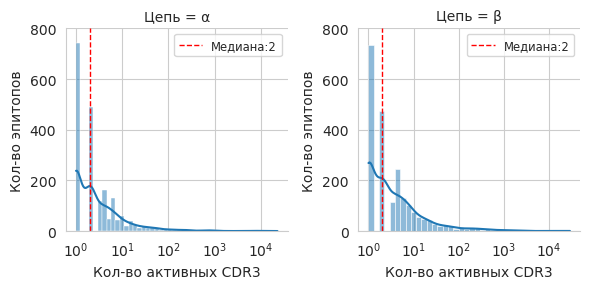

In [169]:
g = sns.FacetGrid(tcr_epitope_stat_total,
                  col = "Цепь",
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  col_order = ["α","β"],
                 ylim = (0,800))
g.map(sns.histplot,"sample_size",log_scale=True, kde=True)
for c, ax in g.axes_dict.items():
    median_val = tcr_epitope_stat_total[(tcr_epitope_stat_total['Цепь'] == c)]['sample_size'].median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1, label=f'Медиана:{median_val:.0f}')
    ax.legend(fontsize="small")
    ax.set_ylabel("Кол-во эпитопов")
    ax.set_xlabel("Кол-во активных CDR3")
g.tight_layout()
plt.savefig("../plots/tmp/sample_sizes_distr_epitope.png", dpi = 400)

In [152]:
total_mhc = total.filter(items = ['cdr3_alpha','cdr3_beta','mhc'])
tcr_mhc_stat = pd.melt(
    total_mhc,
    id_vars=['mhc'],  # Keep epitope as identifier
    value_vars=['cdr3_alpha', 'cdr3_beta'],  # Columns to reshape
    var_name='chain',  # New column name for chain type
    value_name='cdr3'   # New column name for CDR3 sequences
).dropna()
print(tcr_mhc_stat.shape)
tcr_mhc_stat.tail()

(292176, 3)


,mhc,chain,cdr3
381363,HLA-B*57:03/B2M,cdr3_beta,CSARAGTKTYEQYF
381364,HLA-B*57:03/B2M,cdr3_beta,CVSEDSSDGANYGYTF
381365,HLA-B*57:03/B2M,cdr3_beta,CASSPDRARDGYTF
381366,HLA-B*57:03/B2M,cdr3_beta,CASSLGASISYEQYF
381367,HLA-B*57:03/B2M,cdr3_beta,CASSSWEGLDTQYF


In [154]:
tcr_mhc_stat_total = tcr_mhc_stat.\
groupby(["chain","mhc"]).\
agg(
    sample_size=pd.NamedAgg(column='cdr3', aggfunc='nunique')
).\
reset_index(drop = False)

tcr_mhc_stat_total["chain"] = tcr_mhc_stat_total["chain"].map({"cdr3_alpha":"α","cdr3_beta":"β"})
tcr_mhc_stat_total = tcr_mhc_stat_total.rename(columns = {"chain":"Цепь"})
tcr_mhc_stat_total.head()

,Цепь,mhc,sample_size
0,α,H2-AA*b/H2-AB*b,63
1,α,H2-AA*d/H2-AB*d,4
2,α,H2-AA*d/H2-AB*g7,7
3,α,H2-AA*k/H2-AB*k,19
4,α,H2-AA*u/H2-AB*u,1


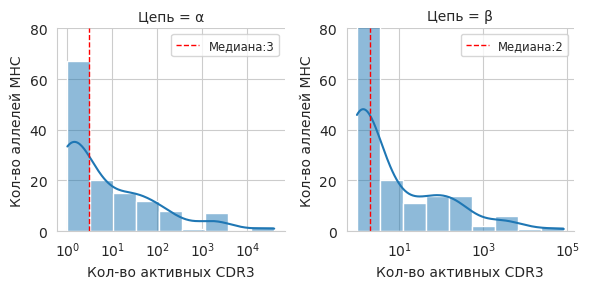

In [170]:
g = sns.FacetGrid(tcr_mhc_stat_total,
                  col = "Цепь",
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  col_order = ["α","β"],
                  ylim = (0,80))
g.map(sns.histplot,"sample_size",log_scale=True, kde=True)
for c, ax in g.axes_dict.items():
    median_val = tcr_mhc_stat_total[(tcr_mhc_stat_total['Цепь'] == c)]['sample_size'].median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1, label=f'Медиана:{median_val:.0f}')
    ax.legend(fontsize="small")
    ax.set_ylabel("Кол-во аллелей MHC")
    ax.set_xlabel("Кол-во активных CDR3")
g.tight_layout()
plt.savefig("../plots/tmp/sample_sizes_distr_mhc.png", dpi = 400)

## v2023 vs v2026

In [319]:
v2023 = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/*/*.HST")
v2023[0:5]

['/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/beta/human-u_cdr3beta_mhc_0_6.HST',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/beta/human-u_cdr3beta_mhc_0_3.HST',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/beta/mouse-u_cdr3beta_mhc_0_12.HST',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/beta/mouse-u_cdr3beta_epitope_0_3.HST',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/results_v2025/old/beta/human-u_cdr3beta_epitope_0_7.HST']

In [320]:
v2023_meta = pd.DataFrame(v2023,columns = ['path'])
v2023_meta['filename'] = v2023_meta['path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
v2023_meta[['type', 'chain', 'activity', 'fold', 'mna_level']] = v2023_meta['filename'].str.split("_",expand = True)
v2023_meta[['species','type_model']] = v2023_meta['type'].str.split("-",expand = True)
v2023_meta = v2023_meta.drop(columns = ['type','type_model','fold'])
v2023_meta.head()

,path,filename,chain,activity,mna_level,species
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_3,cdr3beta,mhc,3,human
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,mouse-u_cdr3beta_mhc_0_12,cdr3beta,mhc,12,mouse
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,mouse-u_cdr3beta_epitope_0_3,cdr3beta,epitope,3,mouse
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_epitope_0_7,cdr3beta,epitope,7,human


In [321]:
def parseTrainLog(log_filepath) -> dict:
    """
    Считывание результатов обучения модели.
    Получает из файла следующие метрики (учитываются только прошедшие внутреннюю валидацию PASS):
    1) инвариантная точность предсказания (IAP)
    2) Размер обучающей выборки (n_train)

    Returns:
        dict: "имя_активности":{"имя_метрики": значение_метрики}

    """    
    val_header = "No	Check	N	IAP	5-F CV	MAP	NN	NP	Prec.	TP	TN	FP	FN	Activity Type"
    val_footer = "Validation MSAR Base time:"
    table_val_start = 0
    table_val_end = 0
    with open(log_filepath, "r") as train_log:
        lines = train_log.readlines()
        for i, line in enumerate(lines):
            if val_header in line:
                table_val_start = i
            if val_footer in line:
                table_val_end = i - 1
    return pd.read_csv(log_filepath, 
                           sep = "\t", 
                           header = 0, 
                           skiprows = table_val_start - 1, 
                           skipfooter = len(lines) - table_val_end, 
                           engine = 'python').\
        rename(str.strip, axis='columns')

In [322]:
v2023_results = []
for i in v2023_meta.path:
    t = parseTrainLog(i)
    t['path'] = i
    v2023_results.append(t)
v2023_results_df = pd.concat(v2023_results, ignore_index = True)
v2023_results_meta = pd.merge(v2023_results_df, v2023_meta, on = 'path')
v2023_results_meta.head()

,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,path,filename,chain,activity,mna_level,species
0,1,Ok,21098,0.7159,0.7159,0.6517,26527,21098,0.5981,13749,17287,9240,7349,HLA-A*02:01,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human
1,2,Ok,264,0.8050,0.7956,0.7230,47361,264,0.0143,191,34244,13117,73,HLA-B*27:05,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human
2,3,Ok,155,0.7446,0.7349,0.6564,47470,155,0.0062,102,31161,16309,53,HLA-B*35:01,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human
3,4,Ok,29,0.8052,0.8222,0.7421,47596,29,0.0018,22,35321,12275,7,HLA-B*35:08,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human
4,5,Ok,91,0.7160,0.7169,0.6545,47534,91,0.0036,60,31112,16422,31,HLA-B*37:01,/projects/rat_gravitation/anton_disser/TCR-Pre...,human-u_cdr3beta_mhc_0_6,cdr3beta,mhc,6,human


In [323]:
v2026 = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/*.csv")
v2026[0:5]

['/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/73c6cc73dd55537da5a7c6386c74da85.csv',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/ee7a44ca8e28636c4d7b7fbc717370d5.csv',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/cbf9a9de1b45aadd72a7b4eac37abe63.csv',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/0939d687a6bb0585eb0b2dd8166ebb48.csv',
 '/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/543881a2946d2ba06bf8807480157c52.csv']

In [324]:
v2026_meta = pd.read_csv("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/output_samplesheet.csv")
v2026_meta['filename'] = v2026_meta['train_file'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
v2026_meta[['chain', 'activity', 'species']] = v2026_meta['filename'].str.split("_",expand = True)
v2026_meta = v2026_meta.filter(items = ['chain', 'activity', 'species','mna_level', 'train_id'])
v2026_meta.head()

,chain,activity,species,mna_level,train_id
0,cdr3alpha,epitope,human,3,5c2f3309493725ecea5c0f318d3c015c
1,cdr3alpha,epitope,human,4,d7f616b6ffb61cbf06fe46e752b57e28
2,cdr3alpha,epitope,human,5,c4817eab89e2be982cfcdae56af7d70d
3,cdr3alpha,epitope,human,6,773315be5594eecb55e31584c2229aeb
4,cdr3alpha,epitope,human,7,c29c8d5bb62ae7bd68db4e5e7daed629


In [325]:
v2026_results = []
for i in v2026:
    id = os.path.splitext(os.path.basename(i))[0]
    t = pd.read_csv(i,sep = ";")
    t['train_id'] = id
    v2026_results.append(t)
v2026_results_df = pd.concat(v2026_results, ignore_index = True)
v2026_results_meta = pd.merge(v2026_results_df, v2026_meta, on = 'train_id')
v2026_results_meta.head()

,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,train_id,chain,activity,species,mna_level
0,1,Ok,3217,0.9090,0.8724,0.7790,130808,3217,0.0798,2506,101901,28907,711,HLA-A*01:01/B2M,134025,0.778987,0.779012,0.201615,0.144770,73c6cc73dd55537da5a7c6386c74da85,cdr3beta,mhc,human,9
1,2,Ok,81776,0.8054,0.7986,0.7100,52249,81776,0.7930,58060,37096,15153,23716,HLA-A*02:01/B2M,134025,0.709988,0.709985,2.363629,0.749202,73c6cc73dd55537da5a7c6386c74da85,cdr3beta,mhc,human,9
2,3,Ok,27717,0.8243,0.8070,0.7164,106308,27717,0.3971,19856,76158,30150,7861,HLA-A*03:01/B2M,134025,0.716383,0.716390,NaN,0.510966,73c6cc73dd55537da5a7c6386c74da85,cdr3beta,mhc,human,9
3,4,Ok,7453,0.8091,0.7933,0.7077,126572,7453,0.1248,5274,89572,37000,2179,HLA-A*11:01/B2M,134025,0.707635,0.707676,0.204817,0.212180,73c6cc73dd55537da5a7c6386c74da85,cdr3beta,mhc,human,9
4,5,Ok,64,0.8565,0.8594,0.7632,133961,64,0.0015,49,102234,31727,15,HLA-A*24:01/B2M,134025,0.765625,0.763162,0.027163,0.002994,73c6cc73dd55537da5a7c6386c74da85,cdr3beta,mhc,human,9


In [326]:
v2026_results_meta['version'] = "v.2026"
v2023_results_meta['version'] = "v.2023"
v2026_results_meta_1 = v2026_results_meta.filter(items = ['N', '5-F CV', 'Activity Type','chain','activity','species','mna_level','version'])
v2023_results_meta_1 = v2023_results_meta.filter(items = ['N', '5-F CV', 'Activity Type','chain','activity','species','mna_level','version'])
total = pd.concat([v2023_results_meta_1,v2026_results_meta_1], ignore_index = True)
total.head()

,N,5-F CV,Activity Type,chain,activity,species,mna_level,version
0,21098,0.7159,HLA-A*02:01,cdr3beta,mhc,human,6,v.2023
1,264,0.7956,HLA-B*27:05,cdr3beta,mhc,human,6,v.2023
2,155,0.7349,HLA-B*35:01,cdr3beta,mhc,human,6,v.2023
3,29,0.8222,HLA-B*35:08,cdr3beta,mhc,human,6,v.2023
4,91,0.7169,HLA-B*37:01,cdr3beta,mhc,human,6,v.2023


In [327]:
total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14914 entries, 0 to 14913
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N              14914 non-null  int64  
 1   5-F CV         14914 non-null  float64
 2   Activity Type  14914 non-null  object 
 3   chain          14914 non-null  object 
 4   activity       14914 non-null  object 
 5   species        14914 non-null  object 
 6   mna_level      14914 non-null  object 
 7   version        14914 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 932.2+ KB


In [328]:
total["mna_level"] = total["mna_level"].astype(int)

In [329]:
total.groupby(["chain","activity","species","mna_level","version"]).agg(
    n_activities=pd.NamedAgg(column='Activity Type', aggfunc='nunique'),
    medianAUC = pd.NamedAgg(column='5-F CV', aggfunc='median')
).reset_index()

,chain,activity,species,mna_level,version,n_activities,medianAUC
0,cdr3alpha,epitope,human,3,v.2023,60,0.81830
1,cdr3alpha,epitope,human,3,v.2026,348,0.82580
2,cdr3alpha,epitope,human,4,v.2023,69,0.80140
3,cdr3alpha,epitope,human,4,v.2026,419,0.83190
4,cdr3alpha,epitope,human,5,v.2023,82,0.78205
5,cdr3alpha,epitope,human,5,v.2026,233,0.86430
6,cdr3alpha,epitope,human,6,v.2023,86,0.80765
7,cdr3alpha,epitope,human,6,v.2026,538,0.86635
8,cdr3alpha,epitope,human,7,v.2023,88,0.81750
9,cdr3alpha,epitope,human,7,v.2026,134,0.88365


In [301]:
from itertools import product
chains = list(total['chain'].unique())
activities = list(total['activity'].unique())
species = list(total['species'].unique())
levels = list(total['mna_level'].unique())
combs = list(product(chains,activities,species,levels))
res = pd.DataFrame(columns = ["chain","activity","species","mna_level","n_act","median","version"])
k = 0
for ch, a, s, l in combs:
    v2023_data = total.query("chain == @ch and activity == @a and species == @s and mna_level == @l and version == 'v.2023'")
    v2026_data = total.query("chain == @ch and activity == @a and species == @s and mna_level == @l and version == 'v.2026'")
    a0 = set(v2023_data["Activity Type"].unique())
    if a == 'mhc':
        v2026_data['edit_mhc'] = v2026_data['Activity Type'].str.split('\/').str[0]
        if s == 'mouse':
            v2023_data['edit_mhc'] = v2023_data['Activity Type'].apply(lambda x: mhcgnomes.parse(x.split(" ")[0]).to_string()).str.split('\/').str[0]
            a0 = set(v2023_data["edit_mhc"].unique())
        a1 = set(v2026_data["edit_mhc"].unique())
    else:
        a1 = set(v2026_data["Activity Type"].unique())
    act = a0.intersection(a1)
    res.loc[k] = [ch, a, s, l, len(act),v2023_data['5-F CV'].median(),'v.2023']
    res.loc[k+1] = [ch, a, s, l, len(act),v2026_data['5-F CV'].median(),'v.2026']
    k += 2    
res.head()

,chain,activity,species,mna_level,n_act,median,version
0,cdr3beta,mhc,human,6,14,0.75950,v.2023
1,cdr3beta,mhc,human,6,14,0.84595,v.2026
2,cdr3beta,mhc,human,3,5,0.74660,v.2023
3,cdr3beta,mhc,human,3,5,0.79715,v.2026
4,cdr3beta,mhc,human,12,20,0.75790,v.2023


In [302]:
res["chain"] = res["chain"].map({"cdr3alpha":"α","cdr3beta":"β"})
res["species"] = res["species"].map({"human":"Человек","mouse":"Мышь"})

In [303]:
mhc = res.query("activity == 'mhc'")
epi = res.query("activity == 'epitope'")

In [304]:
mhc.columns = ["Цепь","Тип активности", "Вид", "Уровень MNA", "Количество общих аллелей", "Медиана ROC AUC","Версия"]
epi.columns = ["Цепь","Тип активности", "Вид", "Уровень MNA", "Количество общих эпитопов", "Медиана ROC AUC","Версия"]

In [305]:
epi.head()

,Цепь,Тип активности,Вид,Уровень MNA,Количество общих эпитопов,Медиана ROC AUC,Версия
40,β,epitope,Человек,6,99,0.7679,v.2023
41,β,epitope,Человек,6,99,0.8850,v.2026
42,β,epitope,Человек,3,43,0.7765,v.2023
43,β,epitope,Человек,3,43,0.8165,v.2026
44,β,epitope,Человек,12,56,0.7883,v.2023


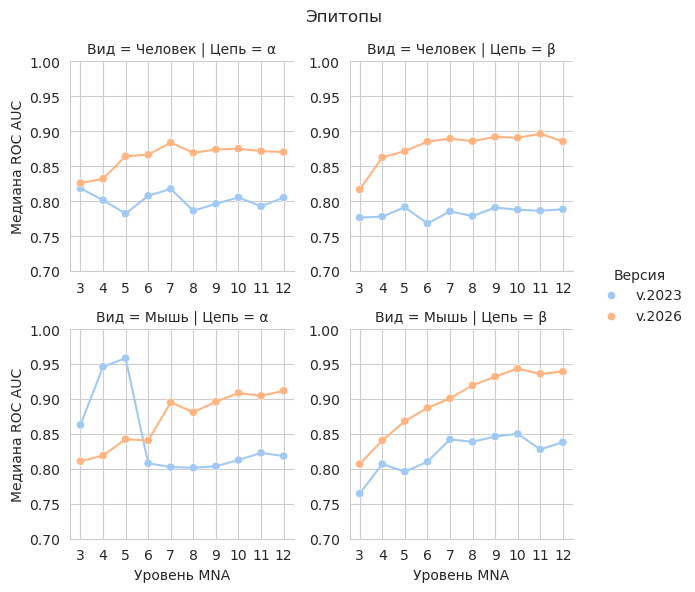

In [310]:
g = sns.FacetGrid(epi,
                  col="Цепь",
                  row="Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],ylim = (0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Версия",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Версия",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Версия")
g.fig.suptitle(f'Эпитопы')
for (s,c), ax in g.axes_dict.items():
    ax.set_xticks(np.arange(3,13,1))
g.tight_layout()
plt.savefig("../plots/tmp/auroc_old_vs_new_epi.png", dpi = 400)

In [317]:
res.query("chain == 'α' and activity == 'epitope' and species == 'Мышь'")

,chain,activity,species,mna_level,n_act,median,version
140,α,epitope,Мышь,6,11,0.8081,v.2023
141,α,epitope,Мышь,6,11,0.8405,v.2026
142,α,epitope,Мышь,3,7,0.8628,v.2023
143,α,epitope,Мышь,3,7,0.8109,v.2026
144,α,epitope,Мышь,12,12,0.8183,v.2023
145,α,epitope,Мышь,12,12,0.9117,v.2026
146,α,epitope,Мышь,7,12,0.8025,v.2023
147,α,epitope,Мышь,7,12,0.8951,v.2026
148,α,epitope,Мышь,5,11,0.9583,v.2023
149,α,epitope,Мышь,5,11,0.8424,v.2026


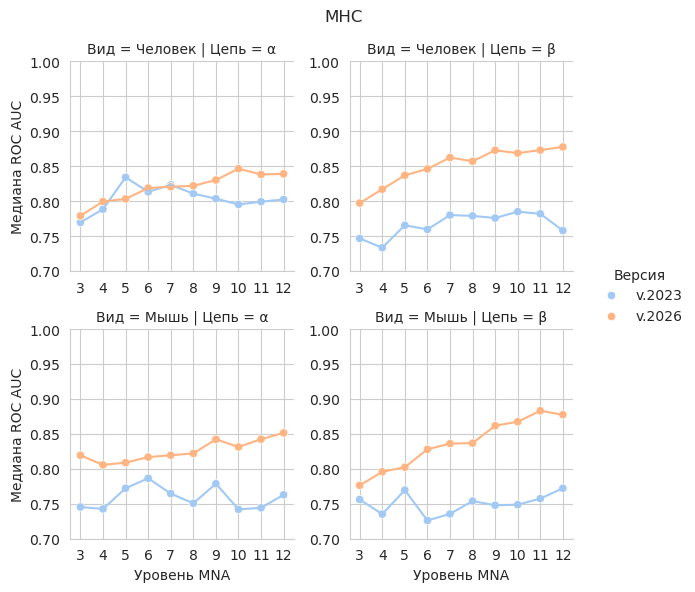

In [311]:
g = sns.FacetGrid(mhc,
                  col="Цепь",
                  row="Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],ylim = (0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Версия",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Версия",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Версия")
g.fig.suptitle(f'MHC')
for (s,c), ax in g.axes_dict.items():
    ax.set_xticks(np.arange(3,13,1))
g.tight_layout()
plt.savefig("../plots/tmp/auroc_old_vs_new_mhc.png", dpi = 400)

## figures

In [171]:
from PIL import Image, ImageDraw, ImageFont
import os

def stack_images_with_annotation(image_paths, direction='vertical', output_name='stacked', 
                               dpi=400, annotations=['А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ё', 'Ж', 'З', 'И'], annotation_font_size=30, 
                               annotation_color='black', annotation_position='top-left'):
    """
    Объединяет изображения с добавлением подписей А, Б, В и т.д.
    
    Parameters:
    image_paths: list of str - пути к изображениям
    direction: str - 'vertical' или 'horizontal'
    output_name: str - имя файла для сохранения
    dpi: int - разрешение
    annotations: list of str or None - кастомные подписи, если None - используются А, Б, В...
    annotation_font_size: int - размер шрифта подписей
    annotation_color: str - цвет подписей
    annotation_position: str - положение подписи ('top-left', 'top-right', 'bottom-left', 'bottom-right')
    """
    
    # Проверяем существование файлов
    for img_path in image_paths:
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Файл не найден: {img_path}")
    
    try:
        # Открываем изображения
        images = [Image.open(img_path) for img_path in image_paths]
        
        # Конвертируем в RGB если нужно
        images = [img.convert('RGB') for img in images]
        
        # Создаем подписи если не указаны
        if annotations is not None:

            # Добавляем подписи к каждому изображению
            annotated_images = []
            for i, (img, annotation) in enumerate(zip(images, annotations)):
                annotated_img = add_annotation_to_image(
                    img, annotation, annotation_font_size, 
                    annotation_color, annotation_position
                )
                annotated_images.append(annotated_img)
        else:
            annotated_images = [i for i in images]
        
        # Выравниваем размеры
        max_width = max(img.width for img in annotated_images)
        max_height = max(img.height for img in annotated_images)
        
        resized_images = []
        for img in annotated_images:
            new_img = Image.new('RGB', (max_width, max_height), (255, 255, 255))
            new_img.paste(img, ((max_width - img.width) // 2, (max_height - img.height) // 2))
            resized_images.append(new_img)
        
        # Объединяем
        if direction == 'vertical':
            total_height = sum(img.height for img in resized_images)
            total_width = max_width
            new_image = Image.new('RGB', (total_width, total_height))
            y_offset = 0
            for img in resized_images:
                new_image.paste(img, (0, y_offset))
                y_offset += img.height
                
        else:  # horizontal
            total_width = sum(img.width for img in resized_images)
            total_height = max_height
            new_image = Image.new('RGB', (total_width, total_height))
            x_offset = 0
            for img in resized_images:
                new_image.paste(img, (x_offset, 0))
                x_offset += img.width
        
        # Сохраняем в разных форматах
        png_path = f"{output_name}.png"
        tiff_path = f"{output_name}.tiff"
        
        new_image.save(png_path, 'PNG', dpi=(dpi, dpi))
        new_image.save(tiff_path, 'TIFF', dpi=(dpi, dpi))
        
        print(f"Успешно сохранено с подписями:")
        print(f"PNG: {png_path} (DPI: {dpi})")
        print(f"TIFF: {tiff_path} (DPI: {dpi})")
        print(f"Подписи: {', '.join(annotations)}")
        
        return new_image
        
    except Exception as e:
        print(f"Ошибка: {e}")
        return None

def add_annotation_to_image(image, annotation, font_size=30, color='black', position='top-left'):
    """
    Добавляет подпись к изображению
    """
    img = image.copy()
    draw = ImageDraw.Draw(img)
    
    # Пытаемся использовать шрифт, если доступен
    try:
        # Попробуем найти подходящий шрифт
        try:
            font = ImageFont.truetype("arial.ttf", font_size)
        except:
            try:
                font = ImageFont.truetype("DejaVuSans.ttf", font_size)
            except:
                font = ImageFont.load_default()
    except:
        font = ImageFont.load_default()
    
    # Получаем размеры текста
    bbox = draw.textbbox((0, 0), annotation, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    # Определяем позицию для подписи
    margin = 10  # отступ от края
    
    if position == 'top-left':
        x = margin
        y = margin
    elif position == 'top-right':
        x = img.width - text_width - margin
        y = margin
    elif position == 'bottom-left':
        x = margin
        y = img.height - text_height - margin
    elif position == 'bottom-right':
        x = img.width - text_width - margin
        y = img.height - text_height - margin
    else:
        x = margin
        y = margin
    
    # Добавляем фон для лучшей читаемости
    bg_margin = 5
    draw.rectangle([
        x - bg_margin, 
        y - bg_margin, 
        x + text_width + bg_margin, 
        y + text_height + bg_margin
    ], fill='white')
    
    # Добавляем текст
    draw.text((x, y), annotation, fill=color, font=font, stroke_width=2, stroke_fill=color)
    
    return img


### Figure 2

Успешно сохранено с подписями:
PNG: ../plots/figure2.png (DPI: 400)
TIFF: ../plots/figure2.tiff (DPI: 400)
Подписи: А, Б, В, Г, Д, Е, Ё, Ж, З, И


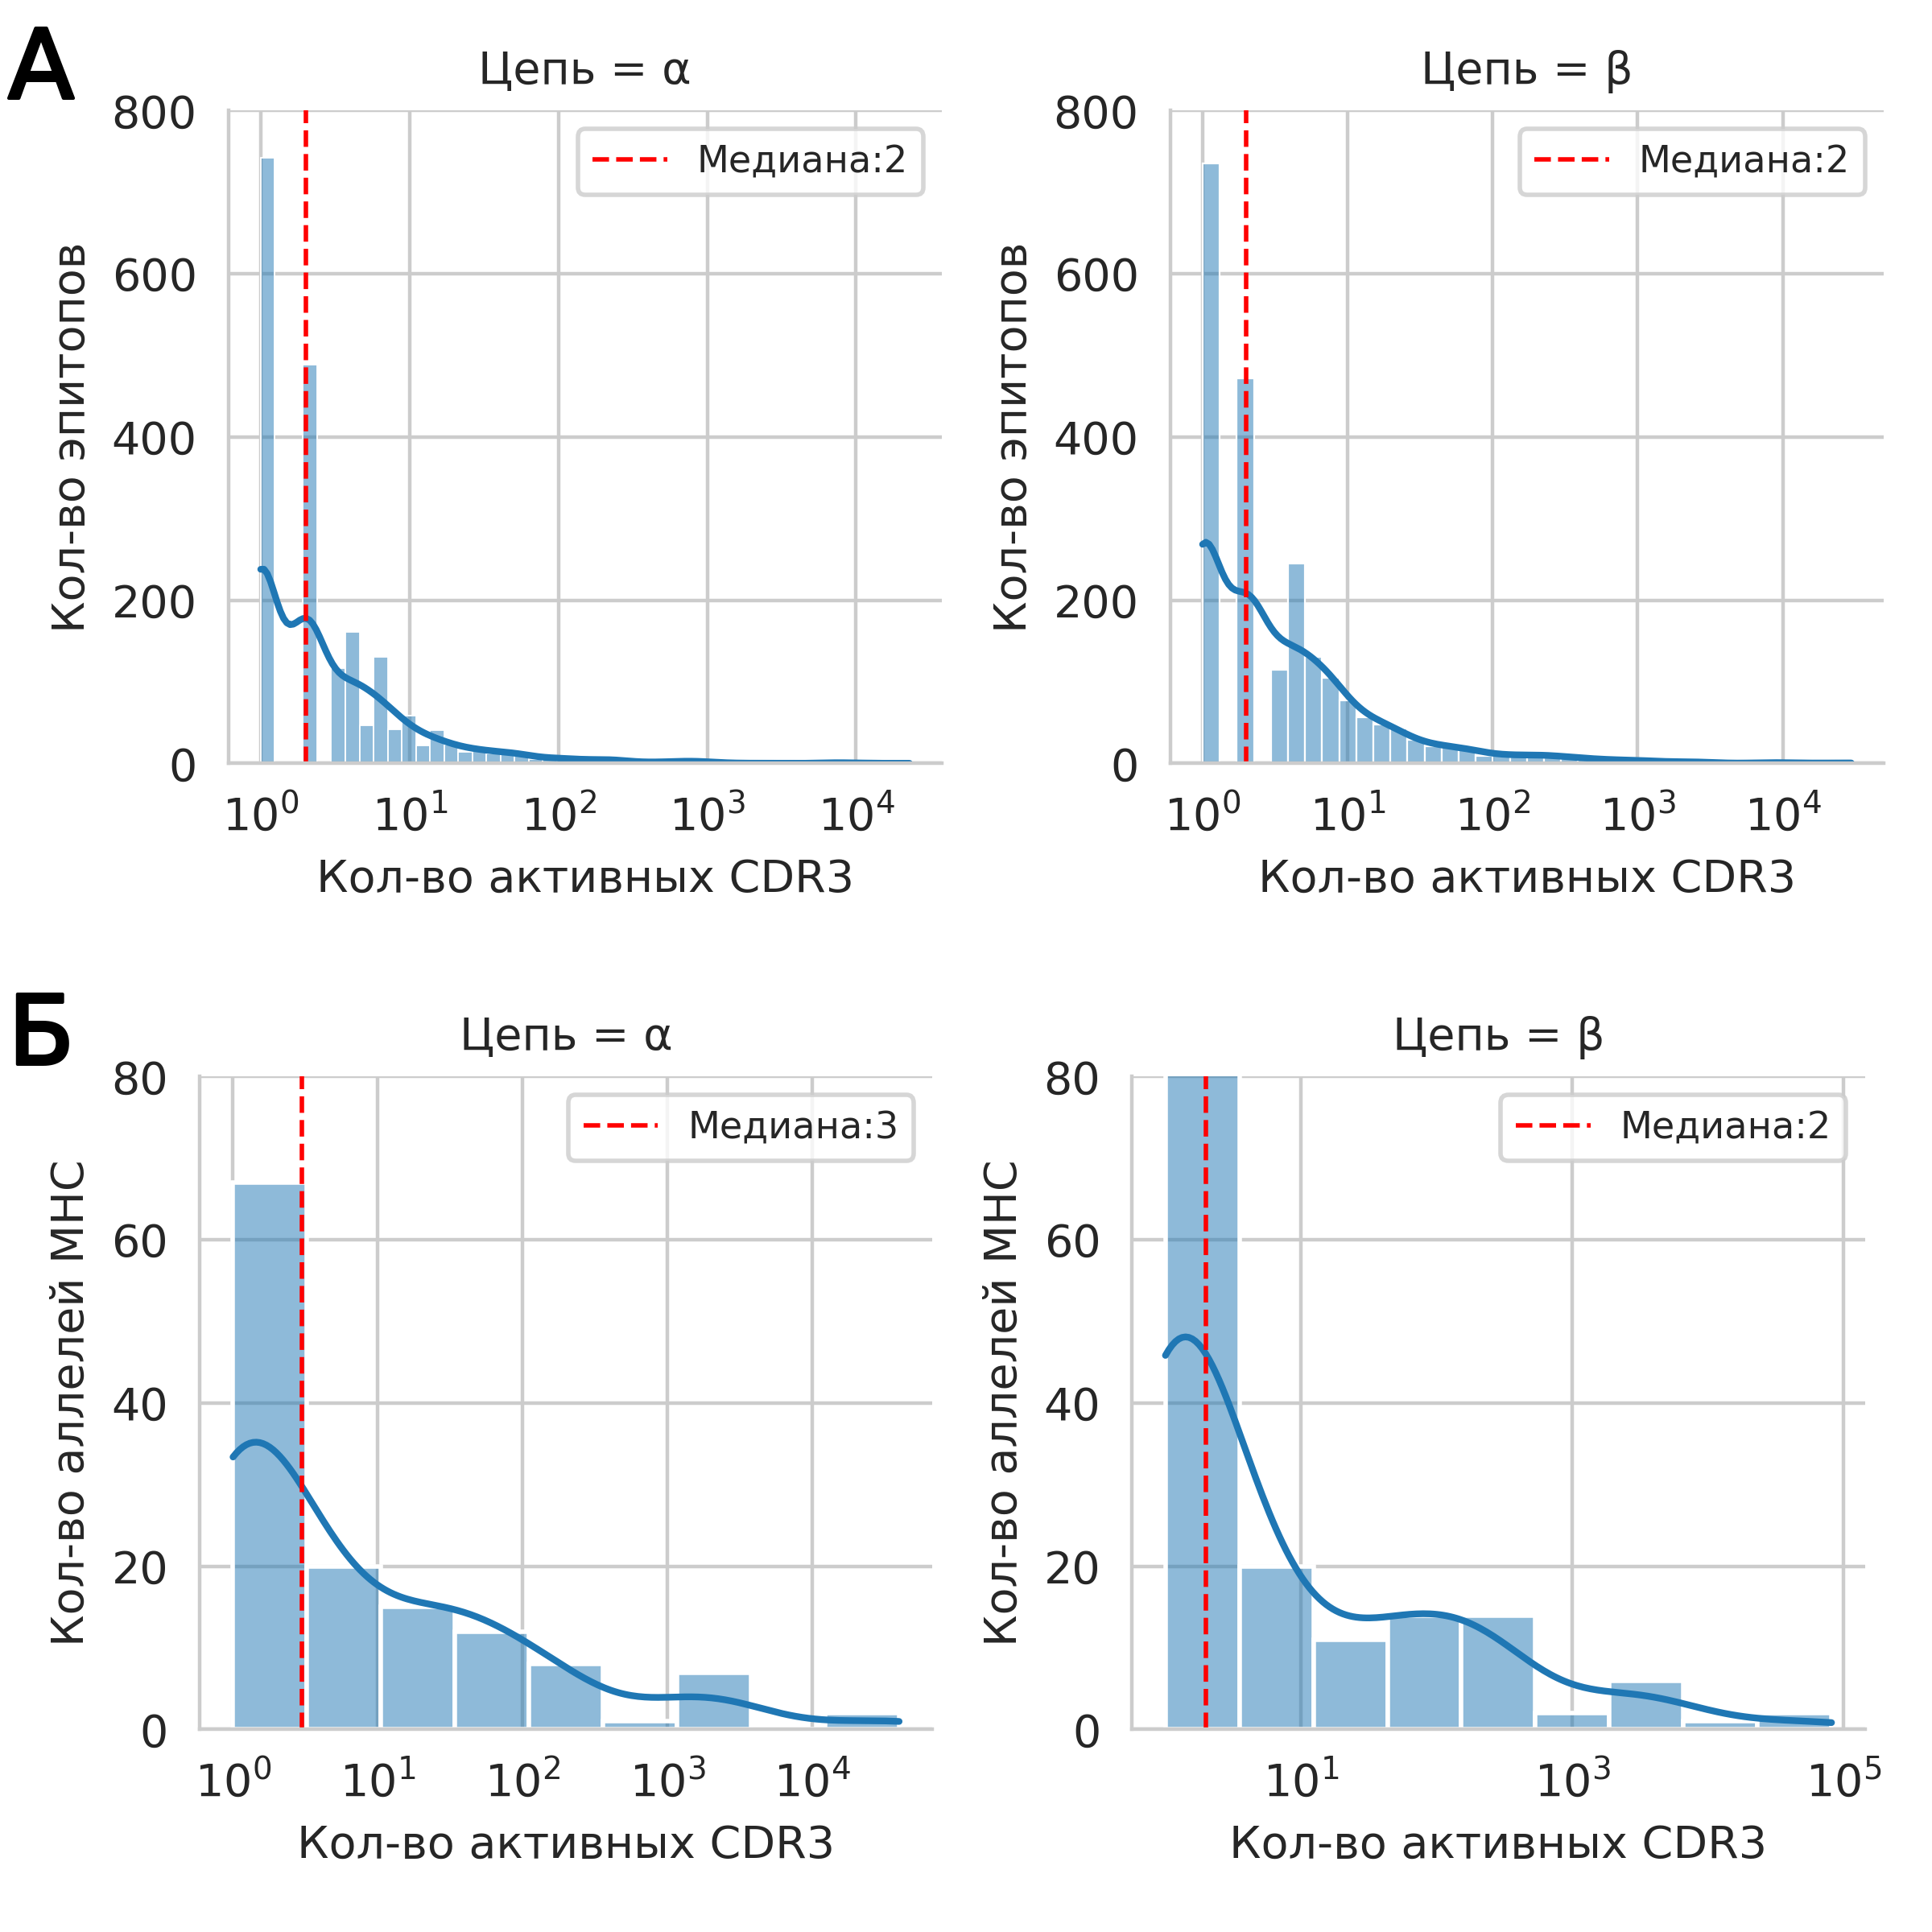

In [172]:
# Пример использования
image_paths = ['../plots/tmp/sample_sizes_distr_epitope.png', 
               '../plots/tmp/sample_sizes_distr_mhc.png']
# Вертикальное объединение
stack_images_with_annotation(image_paths, direction='vertical',annotation_font_size=120, output_name='../plots/figure2', dpi=400)

### Figure 3

Успешно сохранено с подписями:
PNG: ../plots/figure3.png (DPI: 400)
TIFF: ../plots/figure3.tiff (DPI: 400)
Подписи: А, Б, В, Г, Д, Е, Ё, Ж, З, И


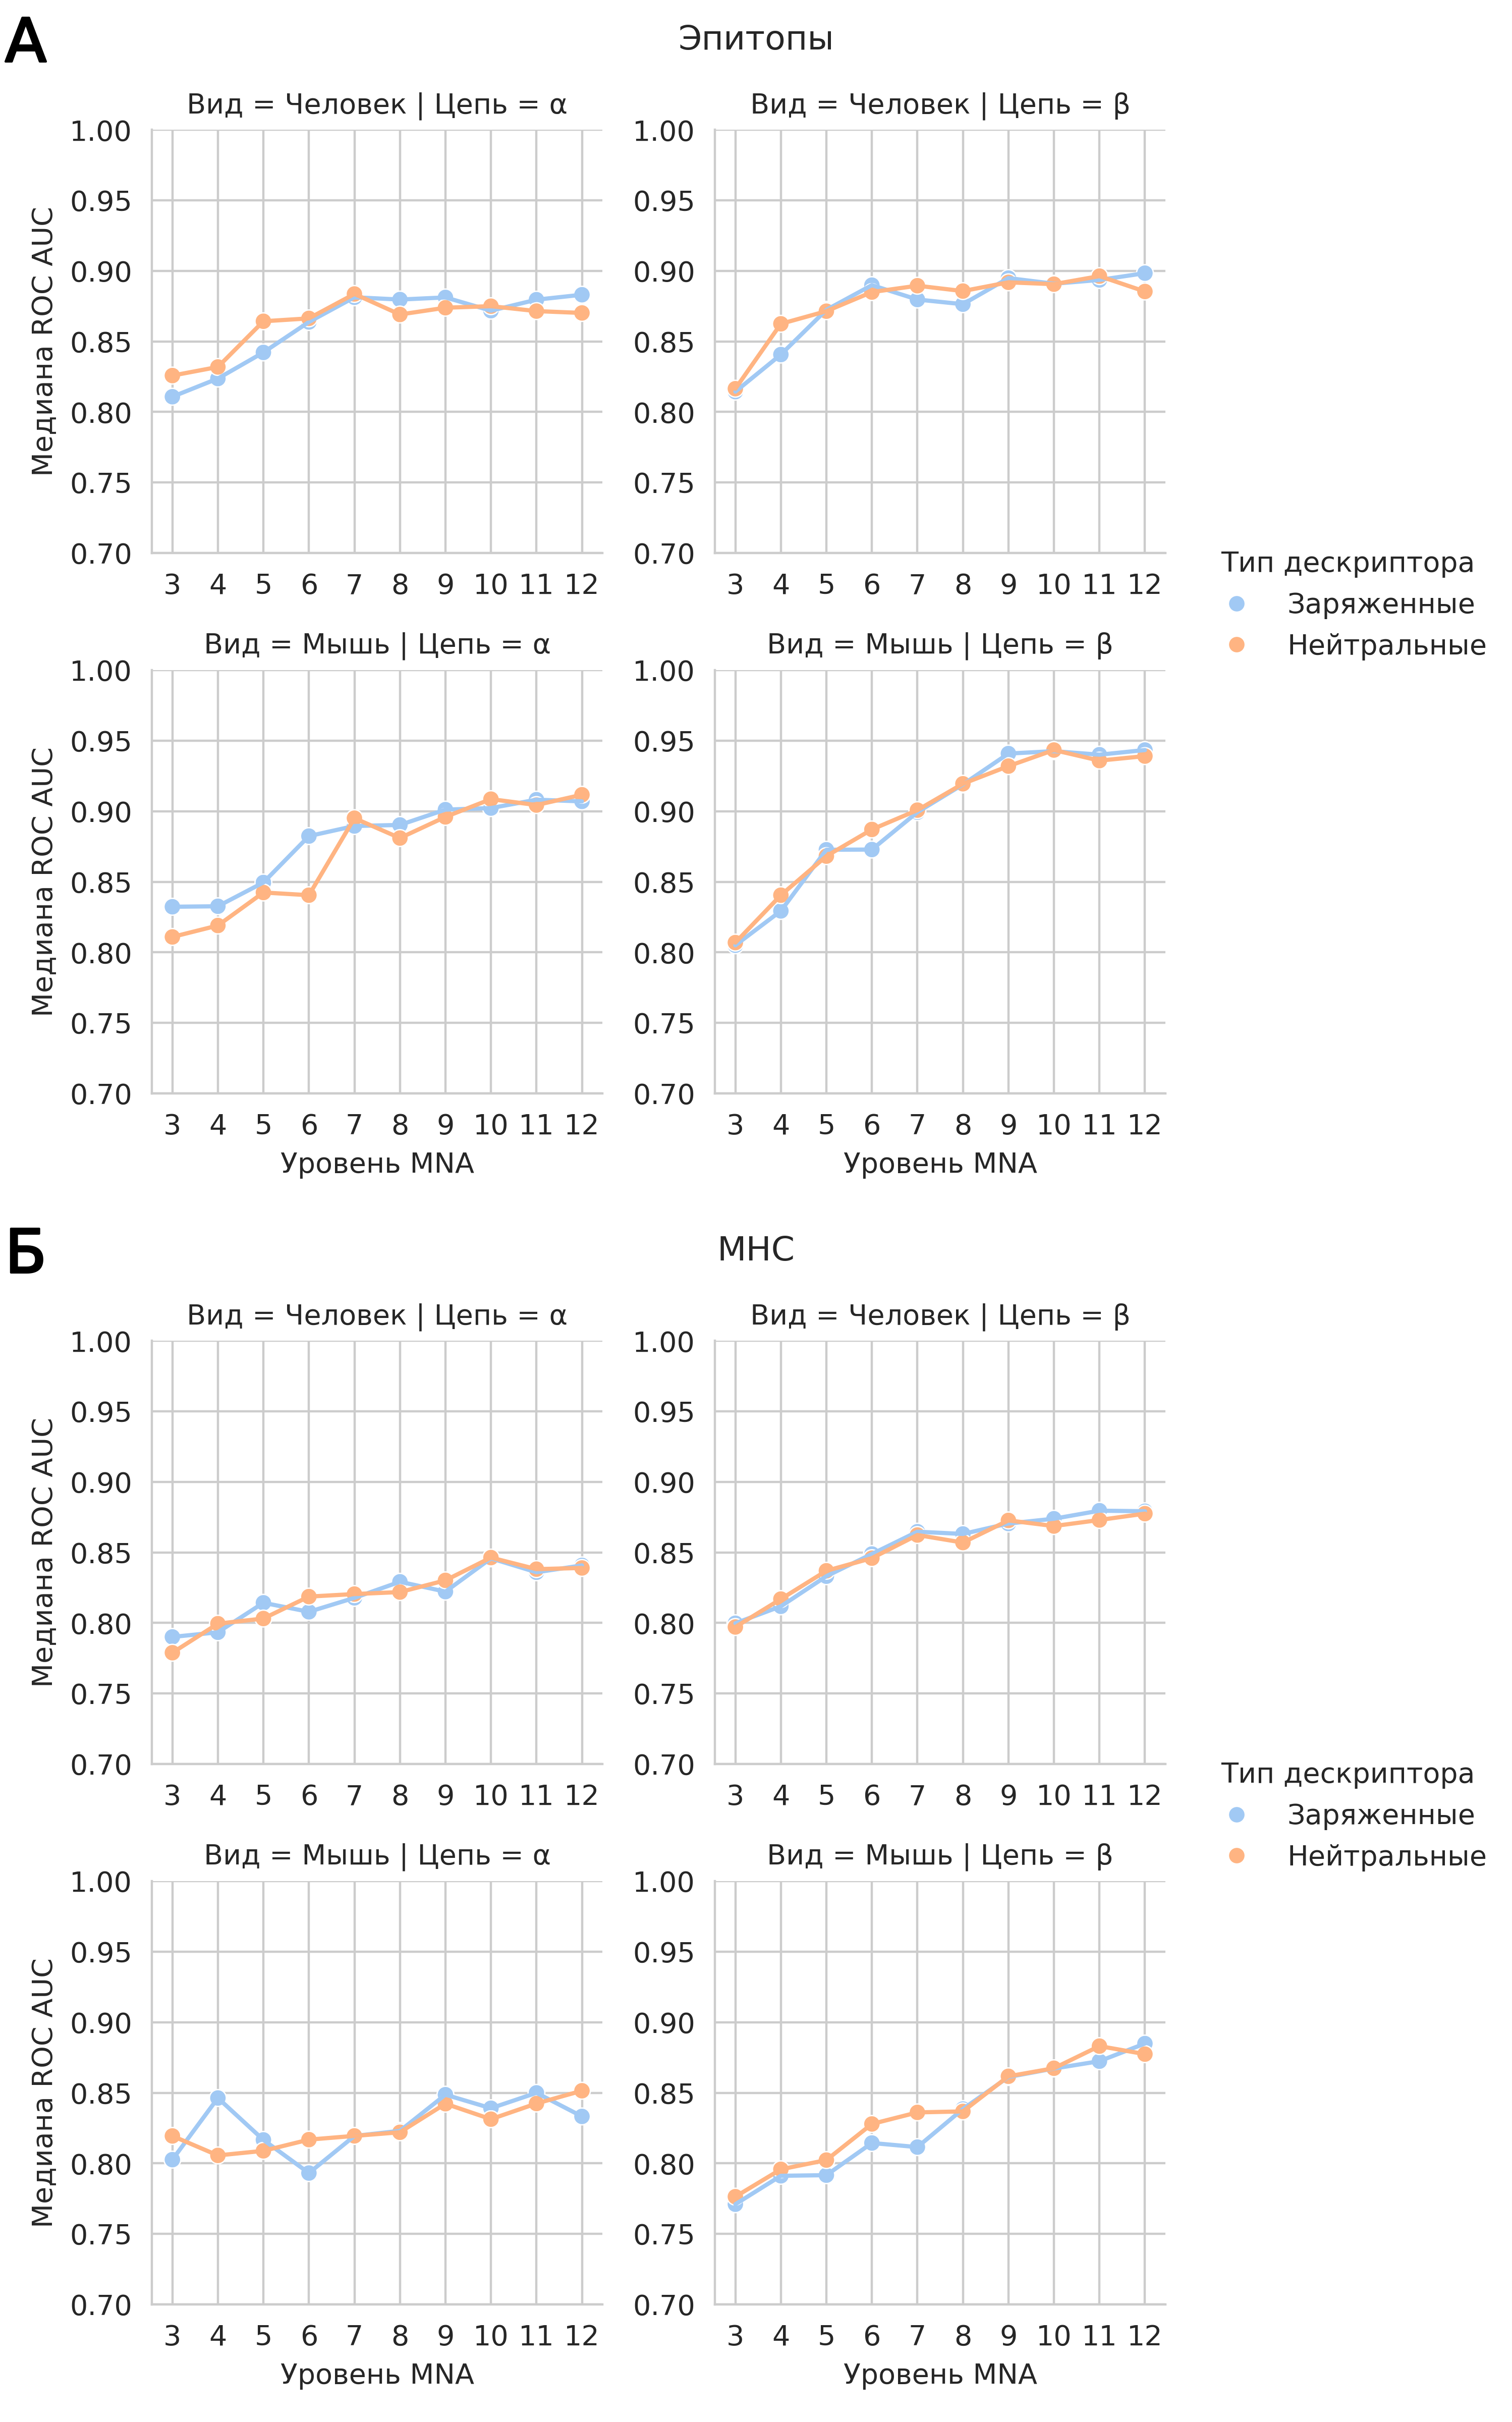

In [195]:
# Пример использования
image_paths = ['../plots/tmp/auroc_ch_vs_n_epi.png', 
               '../plots/tmp/auroc_ch_vs_n_mhc.png']
# Вертикальное объединение
stack_images_with_annotation(image_paths, direction='vertical',annotation_font_size=120, output_name='../plots/figure3', dpi=400)

### Figure 4

Успешно сохранено с подписями:
PNG: ../plots/figure4.png (DPI: 400)
TIFF: ../plots/figure4.tiff (DPI: 400)
Подписи: А, Б, В, Г, Д, Е, Ё, Ж, З, И


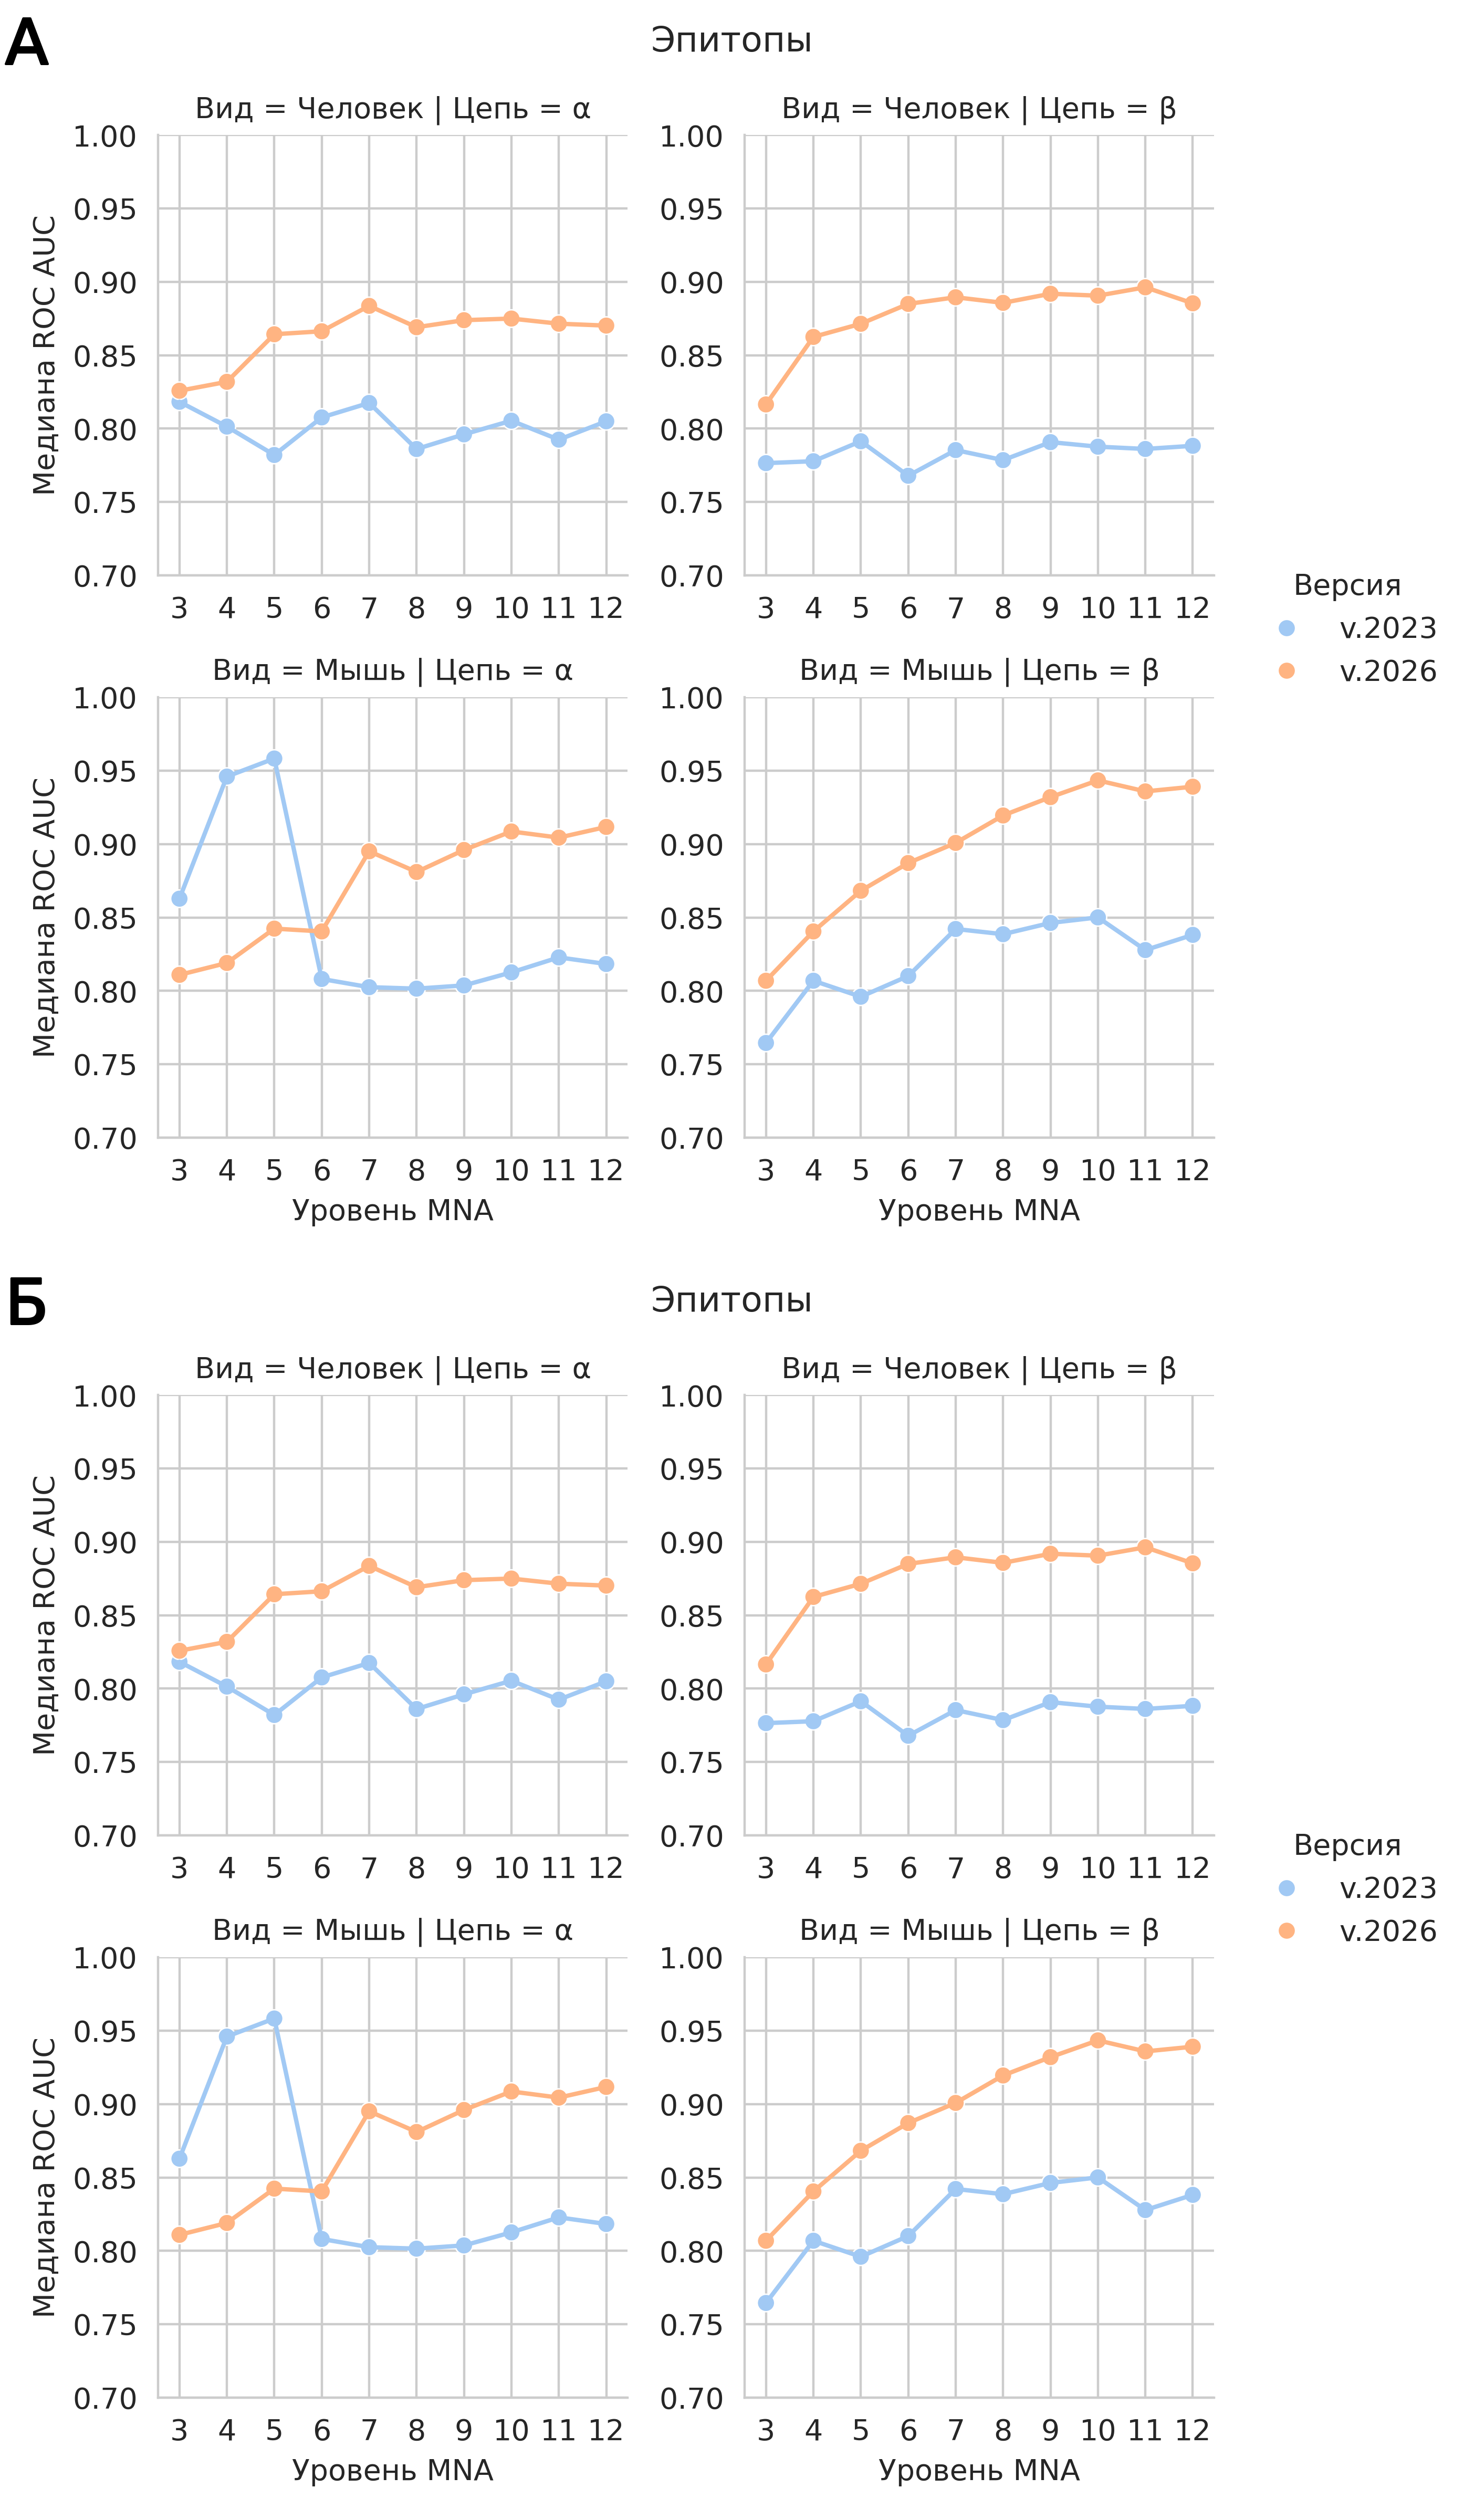

In [312]:
# Пример использования
image_paths = ['../plots/tmp/auroc_old_vs_new_epi.png', 
               '../plots/tmp/auroc_old_vs_new_epi.png']
# Вертикальное объединение
stack_images_with_annotation(image_paths, direction='vertical',annotation_font_size=120, output_name='../plots/figure4', dpi=400)